In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cf
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.colors as mcolors
import pickle
import matplotlib.pyplot as plt
import sys


sys.path.append("../") 
import WRFDomainLib
# Example usage
def plasma_white(vmin=-1, vmax=6):
    # Start with inferno
    inferno = cm.get_cmap("plasma_r", 256)
    # Replace the first color with white
    colors = inferno(np.linspace(0, 1, 256))
    colors[0] = np.array([1, 1, 1, 1])  # RGBA for white
    return mcolors.LinearSegmentedColormap.from_list("plasma_white", colors)
cmap = plasma_white()#inferno_white()

mpl.rcParams['hatch.linewidth'] = 0.1
mpl.rcParams['patch.edgecolor']='none'
WPSFile = '/gpfs/fs7/dfo/hpcmc/pfm/spfm000/CanESM2-WRF/plotting_files/namelist.wps.txt'
wpsproj, latlonproj, corner_lat_full, corner_lon_full, length_x, length_y = WRFDomainLib.calc_wps_domain_info(WPSFile)

seasons = [ 'SON', 'JJA', 'MAM','DJF']


ERROR 1: PROJ: proj_create_from_database: Open of /home/amh001/space_fs7/software_2022/python/py_2024/share/proj failed
/tmp/amh001/1152/ipykernel_1363/893277618.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  inferno = cm.get_cmap("plasma_r", 256)


In [2]:
at=0.1;bt=0.9

# Define grid shape (rows, columns)
nrows = len(seasons)
ncols = 4
sublist=['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o','p', 'q', 'r', 's', 't', 'u']
# Reshape and transpose
subpanel = np.array(sublist[:nrows * ncols]).reshape(nrows, ncols).T.flatten().tolist()

label={"t": r" $\Delta$ T$_{95p}$ ($^\circ$C) ", "tmin":r"$\Delta$ T$_{5p}$ ($^\circ$C)", "pr": '$\Delta_r$ P$_{95p}$ (%)', "wind": '$\Delta_r$ Wspd$_{95p}$ (%)'}
var_cmaps = {"t":plasma_white(0,8),"tmin":plasma_white(0,8), "pr":"BrBG", "wind":"PuOr"}
vlims = {"tmin":(0,8),"t":(0,8), "pr":(-60,60), "wind":(-20,20)}

# Hatching where pval < 0.1
dense_dots = "." * 3  # repeat the dot
hatch_pattern = dense_dots # + " " + dense_dots  # optional spacing


/tmp/amh001/1152/ipykernel_1363/893277618.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  inferno = cm.get_cmap("plasma_r", 256)


In [6]:
def getseasons(var, period, perc, rel, med):
    season_data = {}
    for s in seasons:
        filepath=f'/gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/Extremes/{var}_{s}_{period}_boots_years_1000_perc_{perc}{rel}{med}.pkl'
        print('filepath', filepath)
        # ---- Load results ----
        with open(filepath, "rb") as f:
            data = pickle.load(f)
        perc_delta=data['perc_delta']
        p_val = data["p_value"]
        season_data[s] = (data[f"perc_delta"], data[f"p_value"])
    return season_data

In [7]:
#med is for the percentil minus median results

In [8]:
#seasons = [ 'SON', 'JJA', 'MAM','DJF']
seasons = ["DJF", "MAM", "JJA", "SON"]
var='T2'; period='rcp85'; perc=95; rel=''; med=''
season_data_t = getseasons(var, period, perc, rel, med)
var='pr'; rel='_rel'
season_data_pr = getseasons(var, period, perc, rel, med)
var='wspd'; rel='_rel'
season_data_wind = getseasons(var, period, perc, rel, med)
var='T2';  perc=5; rel=''
season_data_tmin = getseasons(var, period, perc, rel, med)


filepath /gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/Extremes/T2_DJF_rcp85_boots_years_1000_perc_95.pkl
filepath /gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/Extremes/T2_MAM_rcp85_boots_years_1000_perc_95.pkl
filepath /gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/Extremes/T2_JJA_rcp85_boots_years_1000_perc_95.pkl
filepath /gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/Extremes/T2_SON_rcp85_boots_years_1000_perc_95.pkl
filepath /gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/Extremes/pr_DJF_rcp85_boots_years_1000_perc_95_rel.pkl
filepath /gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/Extremes/pr_MAM_rcp85_boots_years_1000_perc_95_rel.pkl
filepath /gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/Extremes/pr_JJA_rcp85_boots_years_1000_perc_95_rel.pkl
filepath /gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/Extremes/pr_SON_rcp85_boots_years_1000_perc_95_rel.pkl
filepath /gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/Extremes/wspd_DJF_rcp85_boots_years_1000_perc_95_rel.pkl
filepath /gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/Extremes/wspd_MAM_rcp85_boots

In [9]:
#load lats and lons like this for now, but need to add to extremes
filepath='/gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/MEANS/seasonal_deltas_and_pvals_pr_rcp85_d03.npz'
data = np.load(filepath)
lat= data ['lat']
lon=data['lon']

In [10]:



#mpl.rcParams['hatch.color'] = 'gray'
def plotseasons(j, count, season_data, axes, seasons, nmodels, var):
#j=0
#count=0
    vmin=vlims[var][0];vmax=vlims[var][1]
    #print(vmin, vmax)
    for i, season in enumerate(seasons):
        ax = axes[i, j] if nmodels > 1 else axes[i]
        field = season_data[season][0]
        pval  = season_data[season][1]
        #print('D3 pvals', np.amax(pval), np.amin(pval))
        # Main colormap
        #print(vmin, vmax)
        mesh = ax.pcolormesh(
            lon, lat, field,
            cmap=var_cmaps[var], vmin=vmin,vmax=vmax,
            transform=ccrs.PlateCarree()    )
        #meshes.append(mesh)
    
        
        cs = ax.contourf(
            lon, lat, pval,
            levels=[0.1, 1],
            colors="none", 
            hatches=[hatch_pattern],  # pass as a list
            transform=ccrs.PlateCarree()
        )
        coastline = cf.COASTLINE.with_scale('10m')
        ax.add_feature(coastline, linewidth=0.1, edgecolor='black')

    
        ax.text(at, bt, subpanel[count], transform=ax.transAxes,  va='top', fontweight='normal',zorder=1000)
        if j==0:
            ax.text(-0.18, 0.6, season, transform=ax.transAxes,  va='top', fontweight='normal',zorder=1000, rotation='vertical')
        #ax.text(.6, 1.1,'D3' , transform=ax.transAxes,  va='top', fontweight='normal',zorder=1000, rotation='vertical')
        ax.set_extent([-129.6, -120.15, 46.4, 51.7], crs=ccrs.PlateCarree())
        
        count+=1

    if i == len(seasons) - 1:  # After last row in the column
        # Get position of the bottom axis in the column
        bbox = ax.get_position()
        # Create a new axis below it for the colorbar
        cbar_ax = fig.add_axes([
            bbox.x0, bbox.y0 - 0.03,  # slightly below the bottom subplot
            bbox.width, 0.015         # same width, small height
        ])
        cbar = fig.colorbar(mesh, cax=cbar_ax, extend='both', orientation="horizontal")
        cbar.set_label(label[var], fontsize=10)
        cbar.set_ticks([vmin,(vmax-abs(vmin))/2,vmax])
    return count

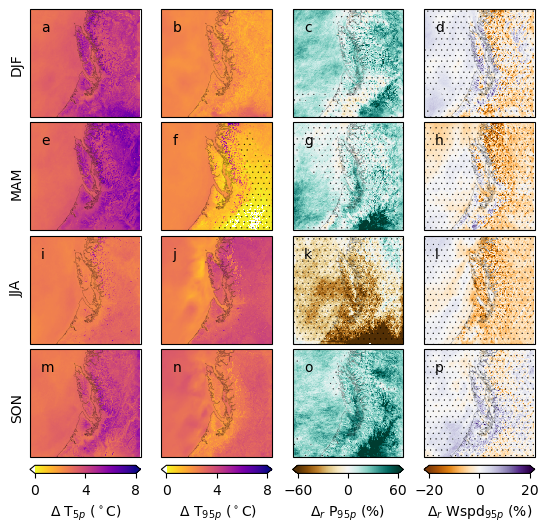

In [11]:


fig, axes = plt.subplots(
        nrows=len(seasons), ncols=ncols,
        figsize=(6.7,5.4),
        subplot_kw={"projection": wpsproj}
    )
fig.subplots_adjust(bottom=0.05, hspace=0.05, wspace=0.05)

count=0
count=plotseasons(0, count, season_data_tmin, axes, seasons, ncols, 'tmin')
count=plotseasons(1, count, season_data_t, axes, seasons, ncols, 't')
count=plotseasons(2, count, season_data_pr, axes, seasons, ncols, 'pr')
count=plotseasons(3, count, season_data_wind, axes, seasons, ncols, 'wind')
plt.savefig('../Figures/Extremes_RCP85.png', format='png', bbox_inches='tight',transparent=False,dpi=500)
#plt.close(fig)

In [12]:
season_data_tmin

{'DJF': (array([[3.03667984, 3.04557012, 3.05383199, ..., 3.92450689, 4.02364184,
          3.96890004],
         [3.02577286, 3.04381154, 3.04687373, ..., 4.73248024, 4.57025579,
          3.97673098],
         [3.01837743, 3.05104243, 3.06809947, ..., 5.0798514 , 4.84250259,
          3.95913442],
         ...,
         [2.76361949, 2.75275218, 2.72521973, ..., 4.01943804, 3.85088323,
          3.46897863],
         [2.76257629, 2.74340617, 2.7310463 , ..., 3.91860911, 3.85337003,
          3.450582  ],
         [2.76397044, 2.73394648, 2.73491211, ..., 3.28991687, 3.33109309,
          3.40900383]]),
  array([[0.   , 0.   , 0.   , ..., 0.002, 0.001, 0.001],
         [0.   , 0.   , 0.   , ..., 0.001, 0.002, 0.001],
         [0.   , 0.   , 0.   , ..., 0.001, 0.001, 0.001],
         ...,
         [0.   , 0.   , 0.   , ..., 0.001, 0.001, 0.001],
         [0.   , 0.   , 0.   , ..., 0.001, 0.001, 0.001],
         [0.   , 0.   , 0.   , ..., 0.001, 0.001, 0.001]])),
 'MAM': (array([[2.92867

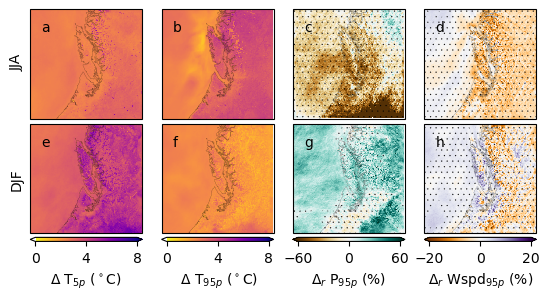

In [13]:
seasons = ['JJA', 'DJF']
#seasons = [ 'SON', 'JJA', 'MAM','DJF']

nrows = len(seasons)
ncols = 4
sublist=['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o','p', 'q', 'r', 's', 't', 'u']
# Reshape and transpose
subpanel = np.array(sublist[:nrows * ncols]).reshape(nrows, ncols).T.flatten().tolist()

#var_cmaps = {"t":'RdBu_r',"tmin":'RdBu_r', "pr":"BrBG", "wind":"PuOr"}
#vlims = {"tmin":(-4,4),"t":(-4,4), "pr":(-80,80), "wind":(-20,20)}
nmodels=4;
# Hatching where pval < 0.1
#label={"t": r"$\Delta$ T$_{95p-50p}$ ($^\circ$C) ", "tmin":r"$\Delta$ T$_{50p-5p}$ ($^\circ$C)", "pr": '$\Delta$ P$_{ 95p-50p}$ (%)', "wind": '$\Delta$ Wspd$_95p-50p$ (%)'}
#label={"t": r" $\Delta$ T$_{ut}$ ($^\circ$C) ", "tmin":r"$\Delta$ T$_{LT}$ ($^\circ$C)", "pr": '$\Delta$ P$_{UT}$ (%)', "wind": '$\Delta$ Wspd$_{UT}$ (%)'}
fig, axes = plt.subplots(
        nrows=len(seasons), ncols=nmodels,
        figsize=(6.7,2.7),
        subplot_kw={"projection": wpsproj}
    )
fig.subplots_adjust(bottom=0.05, hspace=0.05, wspace=0.05)

count=0
count=plotseasons(0, count, season_data_tmin, axes, seasons, nmodels, 'tmin')
count=plotseasons(1, count, season_data_t, axes, seasons, nmodels, 't')
count=plotseasons(2, count, season_data_pr, axes, seasons, nmodels, 'pr')
count=plotseasons(3, count, season_data_wind, axes, seasons, nmodels, 'wind')
plt.savefig('../Figures/Extremes_RCP85_WS.png', format='png', bbox_inches='tight',transparent=False,dpi=500)
plt.show()
plt.close(fig)

In [14]:
#seasons = [ 'SON', 'JJA', 'MAM','DJF']
seasons = ["DJF", "MAM", "JJA", "SON"]

var='T2';  perc=95; rel=''; med='_med50'
season_data_t = getseasons(var, period, perc, rel, med)
var='pr'; rel='_rel'
season_data_pr = getseasons(var, period, perc, rel, '_med75')
var='wspd'; rel='_rel';med='_med50'
season_data_wind = getseasons(var, period, perc, rel, med)
var='T2';  perc=5; rel=''
season_data_tmin = getseasons(var, period, perc, rel, med)


filepath /gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/Extremes/T2_DJF_rcp85_boots_years_1000_perc_95_med50.pkl
filepath /gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/Extremes/T2_MAM_rcp85_boots_years_1000_perc_95_med50.pkl
filepath /gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/Extremes/T2_JJA_rcp85_boots_years_1000_perc_95_med50.pkl
filepath /gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/Extremes/T2_SON_rcp85_boots_years_1000_perc_95_med50.pkl
filepath /gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/Extremes/pr_DJF_rcp85_boots_years_1000_perc_95_rel_med75.pkl


FileNotFoundError: [Errno 2] No such file or directory: '/gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/Extremes/pr_DJF_rcp85_boots_years_1000_perc_95_rel_med75.pkl'

In [ ]:
#seasons = [ 'SON', 'JJA', 'MAM','DJF']
nrows = len(seasons)
subpanel = np.array(sublist[:nrows * ncols]).reshape(nrows, ncols).T.flatten().tolist()

var_cmaps = {"t":'RdBu_r',"tmin":'RdBu_r', "pr":"BrBG", "wind":"PuOr"}
vlims = {"tmin":(-4,4),"t":(-4,4), "pr":(-80,80), "wind":(-20,20)}
nmodels=4;
# Hatching where pval < 0.1
label={"t": r" $\Delta$ T 95p-50p ($^\circ$C) ", "tmin":r"$\Delta$ T 50p-5p ($^\circ$C)", "pr": '$\Delta$ P 95p-75p (%)', "wind": '$\Delta$ Wspd 95p-50p (%)'}
fig, axes = plt.subplots(
        nrows=len(seasons), ncols=nmodels,
        figsize=(6.7,5.4),
        subplot_kw={"projection": wpsproj}
    )
fig.subplots_adjust(bottom=0.05, hspace=0.05, wspace=0.05)

count=0
count=plotseasons(0, count, season_data_tmin, axes, seasons, nmodels, 'tmin')
count=plotseasons(1, count, season_data_t, axes, seasons, nmodels, 't')
count=plotseasons(2, count, season_data_pr, axes, seasons, nmodels, 'pr')
count=plotseasons(3, count, season_data_wind, axes, seasons, nmodels, 'wind')
plt.savefig('../Figures/Extremes_RCP85_median.png', format='png', bbox_inches='tight',transparent=False,dpi=500)
plt.show()
plt.close(fig)

In [ ]:
seasons = ['JJA', 'DJF']
nrows = len(seasons)
ncols = 4
sublist=['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o','p', 'q', 'r', 's', 't', 'u']
# Reshape and transpose
subpanel = np.array(sublist[:nrows * ncols]).reshape(nrows, ncols).T.flatten().tolist()

var_cmaps = {"t":'RdBu_r',"tmin":'RdBu_r', "pr":"BrBG", "wind":"PuOr"}
vlims = {"tmin":(-4,4),"t":(-4,4), "pr":(-80,80), "wind":(-20,20)}
nmodels=4;
# Hatching where pval < 0.1

#label={"t": r" $\Delta$ T$_{ut}$ ($^\circ$C) ", "tmin":r"$\Delta$ T$_{LT}$ ($^\circ$C)", "pr": '$\Delta$ P$_{UT}$ (%)', "wind": '$\Delta$ Wspd$_{UT}$ (%)'}
fig, axes = plt.subplots(
        nrows=len(seasons), ncols=nmodels,
        figsize=(6.7,2.7),
        subplot_kw={"projection": wpsproj}
    )
fig.subplots_adjust(bottom=0.05, hspace=0.05, wspace=0.05)

count=0
count=plotseasons(0, count, season_data_tmin, axes, seasons, nmodels, 'tmin')
count=plotseasons(1, count, season_data_t, axes, seasons, nmodels, 't')
count=plotseasons(2, count, season_data_pr, axes, seasons, nmodels, 'pr')
count=plotseasons(3, count, season_data_wind, axes, seasons, nmodels, 'wind')
plt.savefig('../Figures/Extremes_RCP85_median_WS.png', format='png', bbox_inches='tight',transparent=False,dpi=500)
plt.show()
plt.close(fig)

In [ ]:
seasons = [ 'SON', 'JJA', 'MAM','DJF']

var='T2'; period='rcp85'; perc=95; rel=''; med='_med'
season_data_t = getseasons(var, period, perc, rel, med)
var='pr'; 
season_data_pr = getseasons(var, period, perc, rel, med)
var='wspd';
season_data_wind = getseasons(var, period, perc, rel, med)
var='T2';  perc=5; 
season_data_tmin = getseasons(var, period, perc, rel, med)


In [ ]:
nrows = len(seasons)
sublist=['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o','p', 'q', 'r', 's', 't', 'u']
# Reshape and transpose
subpanel = np.array(sublist[:nrows * ncols]).reshape(nrows, ncols).T.flatten().tolist()

label={"t": r" $\Delta$ T 95p-50p ($^\circ$C) ", "tmin":r"$\Delta$ T 50p-5p ($^\circ$C)", "pr": '$\Delta$ P 95p-50p (mm/day)', "wind": '$\Delta$ Wspd 95p-50p (m/s)'}
vlims = {"tmin":(-4,4),"t":(-4,4), "pr":(-10,10), "wind":(-1,1)}
nmodels=4;


fig, axes = plt.subplots(
        nrows=len(seasons), ncols=nmodels,
        figsize=(6.7,5.4),
        subplot_kw={"projection": wpsproj}
    )
fig.subplots_adjust(bottom=0.05, hspace=0.05, wspace=0.05)

count=0
count=plotseasons(0, count, season_data_tmin, axes, seasons, nmodels, 'tmin')
count=plotseasons(1, count, season_data_t, axes, seasons, nmodels, 't')
count=plotseasons(2, count, season_data_pr, axes, seasons, nmodels, 'pr')
count=plotseasons(3, count, season_data_wind, axes, seasons, nmodels, 'wind')
#plt.savefig('../Figures/Extremes_RCP45_median_abs.png', format='png', bbox_inches='tight',transparent=False,dpi=500)
plt.show()

In [ ]:
plt.close(fig)


In [ ]:
import pickle
import numpy as np

# Base filename
base = "/gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/Extremes/T2_DJF_rcp85_boots_1000_perc_5"

# Versions to compare
versions = [ "_med", ""]

import pickle
import numpy as np

# Base filename
#base = "/gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/Extremes/T2_DJF_rcp45_boots_1000_perc_95"

# Versions to compare


# Load all files
data = {}
for v in versions:
    path = f"{base}{v}.pkl"
    with open(path, "rb") as f:
        data[v] = pickle.load(f)

# Compare dictionaries
for i, v1 in enumerate(versions):
    for v2 in versions[i+1:]:
        print(f"\n--- Comparing {v1} vs {v2} ---")
        
        # Keys must match
        keys1, keys2 = set(data[v1].keys()), set(data[v2].keys())
        if keys1 != keys2:
            print("  Different keys!")
            print("  Only in", v1, ":", keys1 - keys2)
            print("  Only in", v2, ":", keys2 - keys1)
            continue

        # Compare each key
        for k in keys1:
            arr1, arr2 = np.array(data[v1][k]), np.array(data[v2][k])
            same_shape = arr1.shape == arr2.shape
            allclose = np.allclose(arr1, arr2, equal_nan=True) if same_shape else False
            diff = np.nanmax(np.abs(arr1 - arr2)) if same_shape else None

            print(f"  Key: {k}")
            print(f"    Same shape? {same_shape}")
            print(f"    All values equal (within tolerance)? {allclose}")
            if diff is not None:
                print(f"    Max absolute difference: {diff}")
